Вопрос: Как влияет количество комнат на стоимость и цену за м² при фиксированном метраже?

Гипотеза: При одинаковой площади квартиры с большим числом комнат цена за м² выше, так как это «раздробленное» пространство и более удобная планировка

Question: How does the number of rooms affect the cost and the price per м² for a fixed square footage?

Hypothesis: With the same area of an apartment with a large number of rooms, the price per м² is higher, since this is a "fragmented" space and a more convenient layout.


Данные из [датасета](https://www.kaggle.com/datasets/laurabarreda/rental-listins-in-idealista-spain) объявлений об аренде жилья в различных регионах Испании.
Описание колонок:

* `numero` – идентификационный номер объявления
* `provincia` – провинция
* `comunidad autonoma` – автономное сообщество
* `titulo` – заголовок объявления
* `precio` – стоимость аренды в месяц
* `habitaciones` – кол-во комнат
* `metros` – площадь жилья в кв.м.
* `total inmuebles/comunidad` – Total of listings in the given province

# 1. Fixing the data

In [2]:
import pandas as pd
import re
from scipy import stats
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

df = pd.read_csv('rent_spain.csv', sep=',')
df.head(10)

,numero,provincia,comunidad autonoma,titulo,precio,habitaciones,metros
0,45736,Madrid,Madrid,"Estudio en Arturo Soria, 52, Concepción, Madrid",695.0,NaN,Planta 1ª exterior con ascen
1,29804,Granada,Andalucia,"Piso en calle Alondra, 5, Los Pajaritos, Granada",595.0,3.0,87
2,26457,Castellon de la Plana,Comunidad Valenciana,"Dúplex en Zona Playa de la Concha, Oropesa del...",1100.0,4.0,385
3,62732,Ourense,Galicia,"Piso en Casco Viejo, Ourense",575.0,2.0,60
4,56688,Malaga,Andalucia,"Piso en avenida de las Mimosas, 10, Puerto Ban...",3400.0,2.0,197
5,36490,Las Palmas de Gran Canaria,Canarias,"Piso en PRIMERO DE MAYO, Triana, Las Palmas de...",800.0,2.0,65
6,49487,Madrid,Madrid,"Estudio en Malasaña-Universidad, Madrid",900.0,NaN,Planta 1ª interior con ascen
7,27940,Cordoba,Andalucia,"Piso en Centro, Córdoba",850.0,3.0,120
8,40247,Madrid,Madrid,"Piso en calle de Castelló, 124, Castellana, Ma...",5220.0,3.0,120
9,18709,Barcelona,Cataluña,"Ático en avenida Diagonal, Sant Gervasi - Galv...",2600.0,2.0,150


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79754 entries, 0 to 79753
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   numero              79754 non-null  int64  
 1   provincia           79754 non-null  object 
 2   comunidad autonoma  79399 non-null  object 
 3   titulo              79751 non-null  object 
 4   precio              79750 non-null  float64
 5   habitaciones        76050 non-null  float64
 6   metros              79740 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 4.3+ MB


Колонка metros имеет некорректный тип данных. Посмотрим, что может быть не так

The metros column has an incorrect data type. Let's see what might be wrong

In [4]:
df.sort_values(by='metros').head(25)

,numero,provincia,comunidad autonoma,titulo,precio,habitaciones,metros
34159,77240,Vizcaya,Pais Vasco,"Estudio en Gabriel Aresti Hiribidea, Otxarkoag...",750.0,NaN,con ascen
40370,9728,Badajoz,Extremadura,"Estudio en Huerta Rosales - Valdepasillas, Bad...",580.0,NaN,con ascen
27260,76320,Valladolid,Castilla y Leon,"Estudio en paseo Obregón, La Victoria - El Cab...",595.0,NaN,con ascen
4513,36037,Las Palmas de Gran Canaria,Canarias,"Estudio en calle Cirilo Moreno, 53, Santa Cata...",500.0,NaN,con ascen
60546,70869,Santa Cruz de Tenerife,Canarias,Estudio en avenida Familia de Betancourt y Mol...,700.0,NaN,con ascen
4750,65941,Salamanca,Castilla y Leon,"Estudio en San Bernardo, Salamanca",430.0,NaN,exter
11085,3298,Alicante,Comunidad Valenciana,"Estudio en calle el Tap, 14, Centro - Zona Alt...",285.0,NaN,exter
12639,27723,Cordoba,Andalucia,"Estudio en Ciudad Jardín, Córdoba",550.0,NaN,exter
34903,1795,Alava,Pais Vasco,"Estudio en plaza del Renacimiento, 12, Centro,...",790.0,NaN,exterior con ascen
76327,13480,Barcelona,Cataluña,"Estudio en calle del Portal Nou, Sant Pere - S...",1200.0,NaN,exterior con ascen


В колонку, где должен быть метраж квартиры, попадает еще и некое дополнительное описание, так же согласно [законодательству](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8073340/) Испании минимальная жилая площадь на одного человека равна 20 $m^2$. Нам следует удалить некорректные объявления.

In the column where the square footage of the apartment should be, there is also some additional description, also according to [legislation](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8073340 /) In Spain, the minimum living space per person is 20 $m^2$. We should remove the incorrect ads.

## Filling gaps

In [5]:
df.isnull().sum()

,0
numero,0
provincia,0
comunidad autonoma,355
titulo,3
precio,4
habitaciones,3704
metros,14


There are gaps in titulo, precio,habitaciones and metros

In [6]:
df[df['metros'].isna()]

,numero,provincia,comunidad autonoma,titulo,precio,habitaciones,metros
16668,31019,Granada,Andalucia,"Estudio en Gran Vía, Granada",490.0,NaN,NaN
21371,6435,Almeria,Andalucia,"Estudio en La Envía, Vícar",350.0,NaN,NaN
25512,70341,Tarragona,Cataluña,"Masía en camino ermita, s/n, Garcia",200.0,NaN,NaN
25592,0,La Coruña,Galicia,NaN,NaN,NaN,NaN
39247,8665,Asturias,Asturias,"Piso en avenida cristo de las cadenas, 59, Mon...",500.0,3.0,NaN
39939,30775,Granada,Andalucia,"Ático en Recogidas, Granada",430.0,NaN,NaN
43733,24965,Cantabria,Cantabria,"Casa o chalet independiente en lepanto, 10, El...",5000.0,6.0,NaN
50325,26136,Cantabria,Cantabria,"Casa de pueblo en El Sobardo, 403, Ribamontan ...",250.0,NaN,NaN
56375,28757,Cuenca,Castilla La Mancha,"Castillo en calle Palomar, 1, Valhermoso de la...",200.0,3.0,NaN
62929,8496,Asturias,Asturias,"Piso en calle Daniel Moyano, 8, Corredoria-La ...",560.0,2.0,NaN


Gaps in metros: there are only 12 gaps and a half of them have gaps in rooms so we can delete them all without significant losses

In [7]:
df.dropna(subset='metros', inplace=True)

Lets look at text values in metros

In [8]:
#We'll find ads where the meters field is written with letters
# -> see how many of them are without specifying rooms
#-> leave only entries with rooms > 0, remove duplicates
#-> show among them those that are not designated as "studio" in the title
wrong_data_df = df[df['metros'].str.contains('[A-Za-z]')]
print(len(wrong_data_df), len(wrong_data_df[wrong_data_df['habitaciones'].isna()]))
wrong_data_df_with_hab = wrong_data_df[wrong_data_df['habitaciones'] >0]
wrong_data_df_with_hab = wrong_data_df_with_hab.drop_duplicates(subset=['titulo','precio'])
wrong_data_df_with_hab[~wrong_data_df_with_hab['titulo'].str.startswith('Estudio')] #only 10 not studio

4003 3697


,numero,provincia,comunidad autonoma,titulo,precio,habitaciones,metros
10514,67140,Sevilla,Andalucia,"Dúplex en avenida de Finlandia, 1, Los Bermeja...",1500.0,1.0,Planta 10ª exterior con ascen
26570,37096,Las Palmas de Gran Canaria,Canarias,"Dúplex en calle Utiaca, 10, La Isleta, Las Pal...",1200.0,1.0,Planta 1ª exterior sin ascen
26577,1753,Alava,Pais Vasco,"Dúplex en plaza de Salvador García Bodaño, 6, ...",2000.0,2.0,Planta 3ª exterior con ascen
28099,10926,Islas Baleares,Baleares,"Ático en avenida d'Es Tren, 6, Manacor Centro,...",1199.0,2.0,Planta 1ª exterior sin ascen
43738,1500,La Coruña,Galicia,"Ático en calle Cantón Grande, 7, Ensanche, A C...",2700.0,1.0,Planta 11ª exterior con ascen
53574,26413,Castellon de la Plana,Comunidad Valenciana,"Ático en avenida del Papa Luna, 37, Playa nort...",900.0,1.0,Planta 8ª exterior con ascen
72379,38916,Madrid,Madrid,"Dúplex en calle Maratón, 6, Simancas, Madrid",900.0,1.0,Planta 2ª exterior con ascen
73202,72438,Valencia,Comunidad Valenciana,"Dúplex en avenida Mare Nostrum, La Patacona, A...",2500.0,1.0,Planta 1ª exterior con ascen
74840,38906,Madrid,Madrid,"Dúplex en calle de Cronos, 20, Simancas, Madrid",1100.0,1.0,Planta 1ª exterior con ascen
78019,30993,Granada,Andalucia,Dúplex en Monte los Almendros - El Pargo - Cos...,650.0,2.0,Bajo exterior sin ascen


In [9]:
temp_df = df[(df['habitaciones'] == 1) & (df['provincia'] == 'Madrid')]
temp_df[temp_df['titulo'].str.startswith('Dúplex')] #only 2 of this with wrong data

,numero,provincia,comunidad autonoma,titulo,precio,habitaciones,metros
106,39114,Madrid,Madrid,"Dúplex en calle Antonio Suárez, La Garena, Alc...",750.0,1.0,80
2686,38863,Madrid,Madrid,"Dúplex en costanilla de los Desamparados, Huer...",850.0,1.0,51
6797,39665,Madrid,Madrid,"Dúplex en tarragona, Palos de Moguer, Madrid",690.0,1.0,36
7444,39104,Madrid,Madrid,"Dúplex en calle Riazas, Miraflores de la Sierra",600.0,1.0,50
8138,39175,Madrid,Madrid,"Dúplex en calle de Jesús del Valle, Malasaña-U...",675.0,1.0,35
10942,40000,Madrid,Madrid,"Dúplex en calle del Amparo, Lavapiés-Embajador...",800.0,1.0,35
22243,38611,Madrid,Madrid,"Dúplex en calle Libertad, Chueca-Justicia, Madrid",1150.0,1.0,75
22423,39502,Madrid,Madrid,"Dúplex en Costillares, Madrid",1100.0,1.0,57
25838,38710,Madrid,Madrid,"Dúplex en calle Miguel Yuste, 21, Simancas, Ma...",1400.0,1.0,90
27070,39586,Madrid,Madrid,"Dúplex en calle de Carranza, Trafalgar, Madrid",950.0,1.0,40


В колонке metros 4003 нецифровых значений, в 3697 из которых так же есть пропуск в количестве комнат. Так как в этих случаях отсутсвует информация об объекте недвижимости, логичнее всего будет их удалить. В оставшихся 306 случаях большую часть представляют квартиры типа "студия", которые являются единственными такого типа во всём датасете, следовательно мы не можем "придумать" их метраж, потому что однокомнатная квартира и квартира студия могут иметь разную площадь и, заполняя пропуски для студий, скажем, средним метражом для однокомнатных квартир, мы завысим реальный метраж. Вывод: правильнее всего будет вовсе не учитывать такие квартиры в исследовании, прочие объявления так же можно удалить, так как их количество сравнительно мало.

There are 4003 non-digital values in the metros column, 3697 of which also have a skip in the number of rooms. Since there is no information about the property in these cases, it would be most logical to delete them. In the remaining 306 cases, most of them are studio apartments, which are the only ones of this type in the entire dataset, therefore we cannot "invent" their square footage, because a studio apartment and a studio apartment may have different sizes and, filling in the gaps for studios, say, with the average square footage for studio apartments, we will overestimate real footage. Conclusion: it would be best not to include such apartments in the study at all, other ads can also be deleted, since their number is relatively small.

In [10]:
df['metros'] = df['metros'].str.extract('(\d*\.?\d*)', expand=False).replace('','0').astype(float) #удаляем
df = df[df['metros'] >= 20] #delete ads with less than 20m2
df['metros'] = df['metros'].round().astype('int64') #convert to an integer format
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75634 entries, 1 to 79753
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   numero              75634 non-null  int64  
 1   provincia           75634 non-null  object 
 2   comunidad autonoma  75294 non-null  object 
 3   titulo              75632 non-null  object 
 4   precio              75631 non-null  float64
 5   habitaciones        75634 non-null  float64
 6   metros              75634 non-null  int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 4.6+ MB


<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_911/3434198526.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['metros'] = df['metros'].str.extract('(\d*\.?\d*)', expand=False).replace('','0').astype(float) #удаляем


Разобрались со всеми пропусками. Проверим теперь дубликаты, так как данные собраны скрэпингом они могут быть

Now check duplicates as data's been collected by scraping

In [11]:
df.duplicated().sum()

np.int64(2)

# 2. EDA

In [13]:
# add price per m2 and per room
df['precio per metros'] = df['precio'] / df['metros']
df['precio per habitaciones'] = df['precio'] / df['habitaciones']
df.head()

,numero,provincia,comunidad autonoma,titulo,precio,habitaciones,metros,precio per metros,precio per habitaciones
1,29804,Granada,Andalucia,"Piso en calle Alondra, 5, Los Pajaritos, Granada",595.0,3.0,87,6.839080,198.333333
2,26457,Castellon de la Plana,Comunidad Valenciana,"Dúplex en Zona Playa de la Concha, Oropesa del...",1100.0,4.0,385,2.857143,275.000000
3,62732,Ourense,Galicia,"Piso en Casco Viejo, Ourense",575.0,2.0,60,9.583333,287.500000
4,56688,Malaga,Andalucia,"Piso en avenida de las Mimosas, 10, Puerto Ban...",3400.0,2.0,197,17.258883,1700.000000
5,36490,Las Palmas de Gran Canaria,Canarias,"Piso en PRIMERO DE MAYO, Triana, Las Palmas de...",800.0,2.0,65,12.307692,400.000000


Графики для автономных сообществ

Graphs for autonomous communities



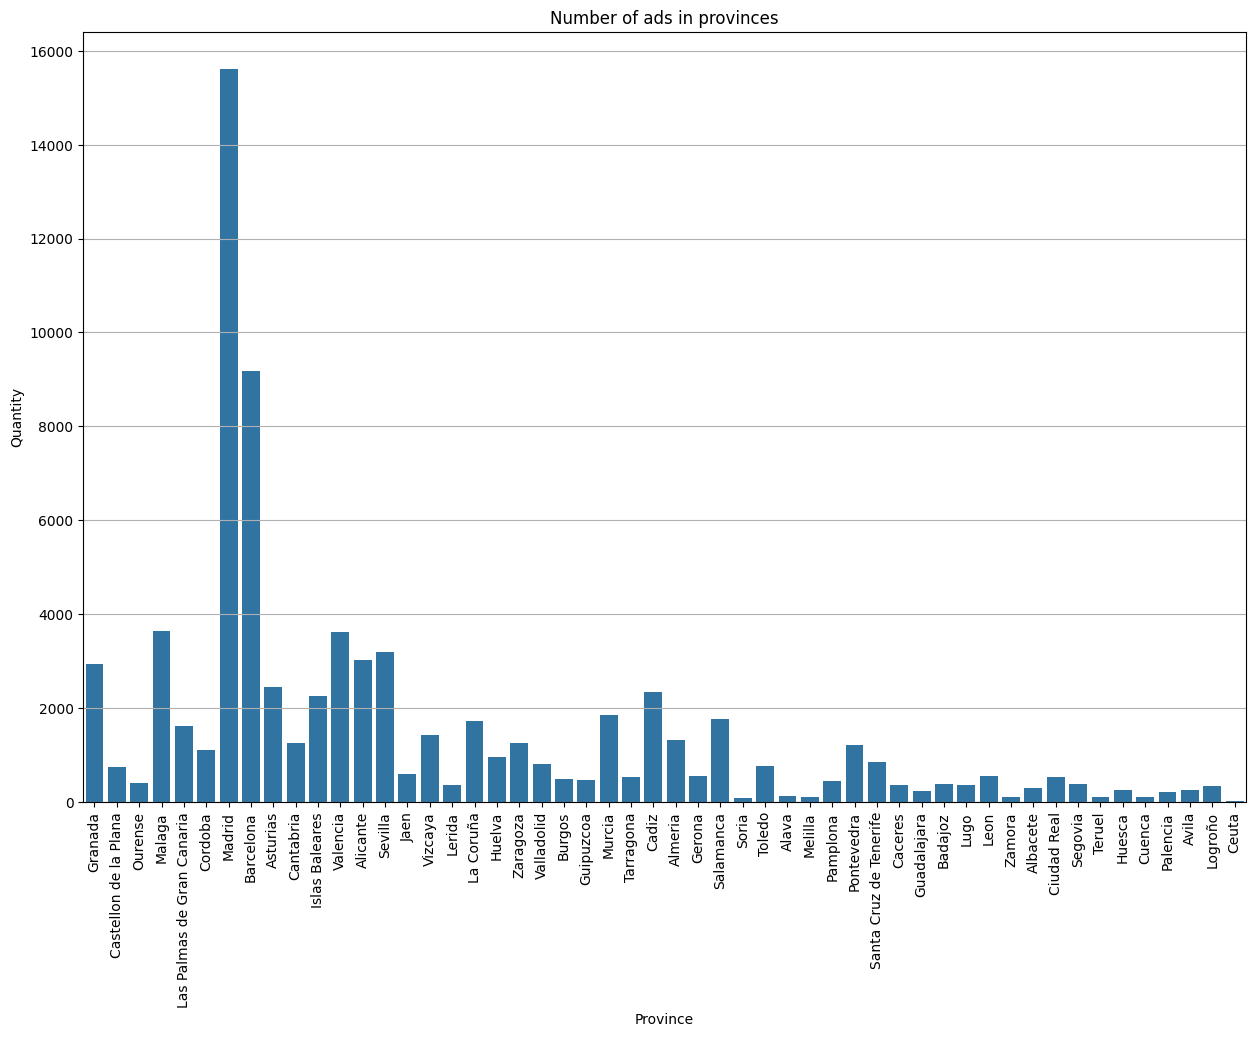

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

plt.figure(figsize=(15,10))
plt.xticks(rotation=90)
plt.grid(True)
fig = sns.countplot(df, x='provincia')

plt.title('Number of ads in provinces')
plt.xlabel('Province')
plt.ylabel('Quantity')

plt.show(fig)

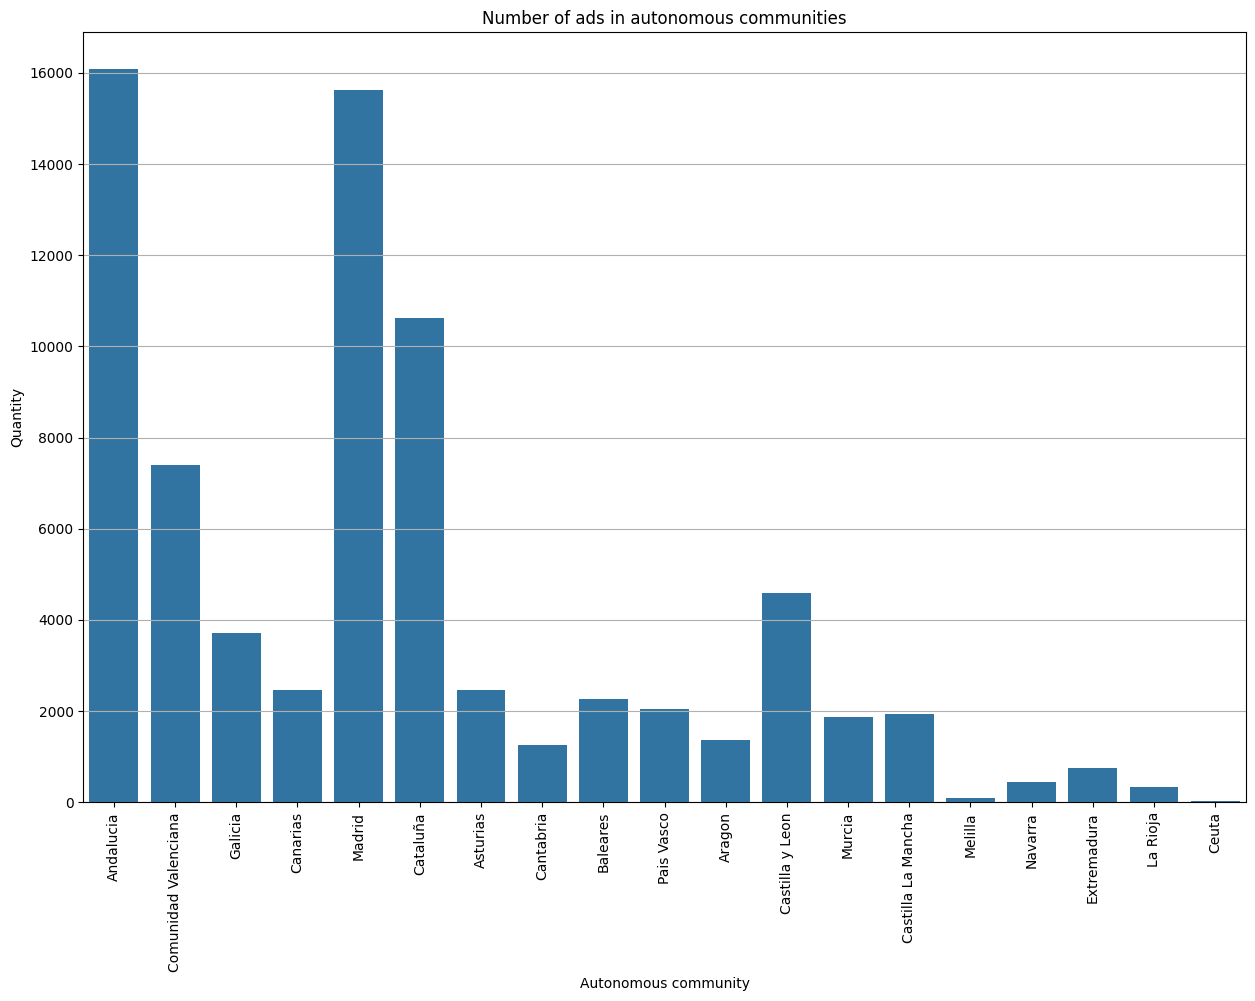

In [15]:
plt.figure(figsize=(15,10))
plt.xticks(rotation=90)
plt.title('Number of ads in autonomous communities')
plt.grid(True)
fig = sns.countplot(df, x='comunidad autonoma')
plt.xlabel('Autonomous community')
plt.ylabel('Quantity')
plt.show(fig)

What we see below:

precio: most of the ads are concentrated in a low range, and expensive apartments make up a small "tail" on the right.

habitaciones: a discrete distribution, where peaks occur in 1-3 rooms, 4-5 rooms are noticeably less common.

metros: most apartments have an area in the range of about 100-120 m2, more spacious options are less common towards the right edge.

precio per metros: the price per square meter is concentrated in a narrow range, and very high values are rare and were additionally cut off by the threshold in the 99th percentile

precio per habitaciones: for most ads, the price per room is in a moderate range, and very expensive options form an elongated right tail.

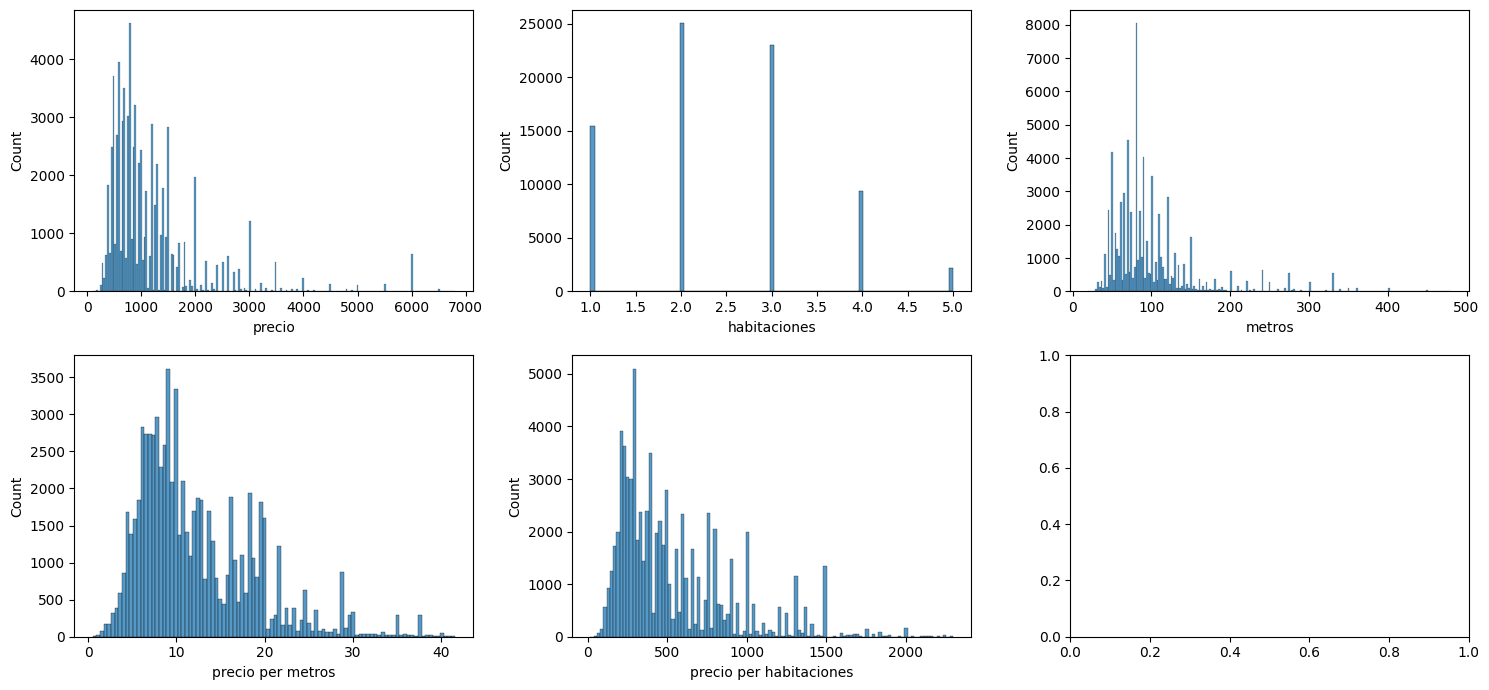

In [16]:
#Let's plot the histograms of distributions based on the main numerical features of the df dataframe
# and trim the extreme outliers by the 99th percentile
num_columns = ['precio','habitaciones','metros','precio per metros', 'precio per habitaciones']
fig, axes = plt.subplots(nrows=2, ncols=3,figsize=(15, 7) )
sns.histplot(x = 'precio', data=df[(df['precio'] <= df['precio'].quantile(0.99))], ax=axes[0,0])
sns.histplot(x = 'habitaciones', data=df[(df['habitaciones'] <= df['habitaciones'].quantile(0.99))], ax=axes[0,1])
sns.histplot(x = 'metros', data=df[(df['metros'] <= df['metros'].quantile(0.99))], ax=axes[0,2])
sns.histplot(x = 'precio per metros', data=df[(df['precio per metros'] <= df['precio per metros'].quantile(0.99))], ax=axes[1,0])
sns.histplot(x = 'precio per habitaciones', data=df[(df['precio per habitaciones'] <= df['precio per habitaciones'].quantile(0.99))], ax=axes[1,1])
fig.tight_layout()
plt.show()

What we see below:

For precio and metros, the distributions are strongly right-sided: most observations are relatively cheap and small, but there are objects with a very high price or area that look like extreme ones.

For habitaciones, the majority of ads have 1-3 rooms, but there are objects with 10, 20 or more rooms, which can be either non-standard objects or input errors.​

precio per metros and precio per habitaciones have a compact "core" and a long tail of very expensive offerings

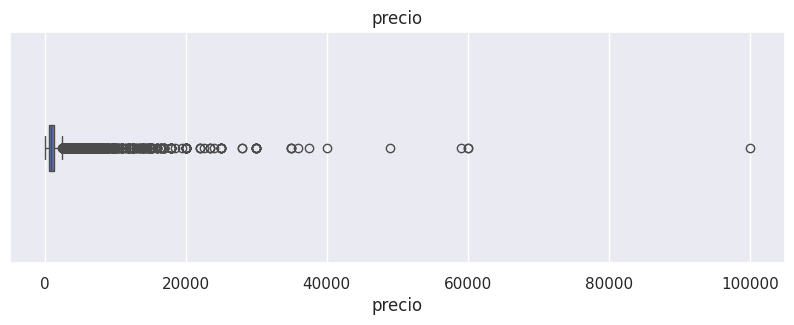

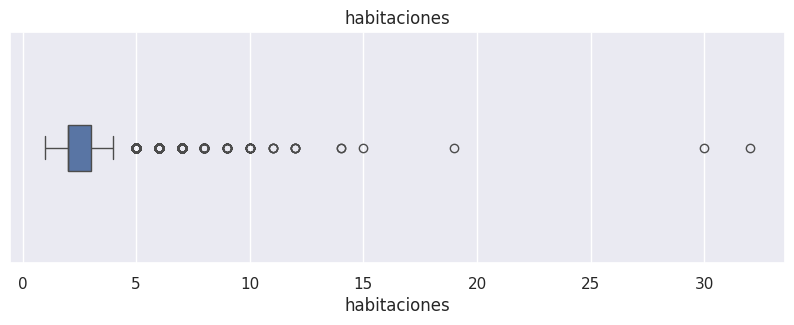

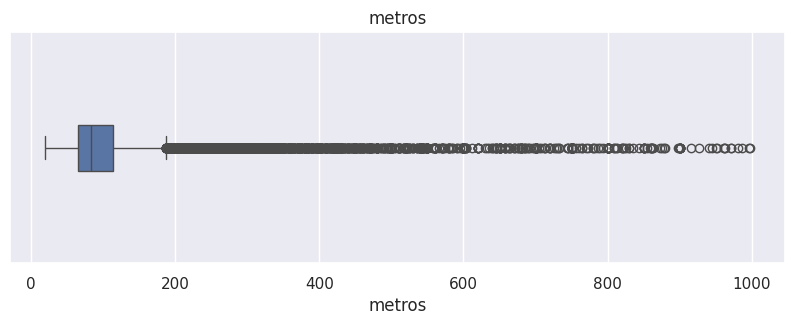

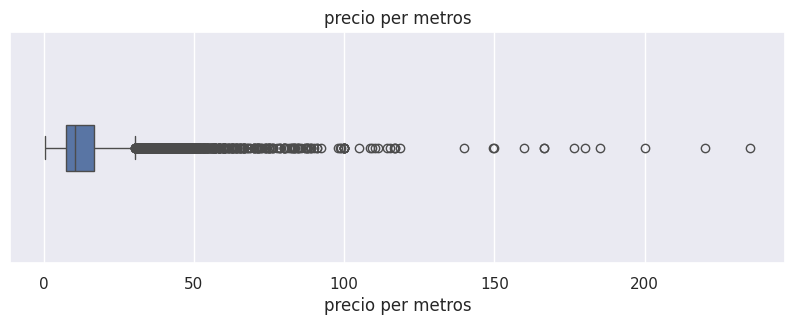

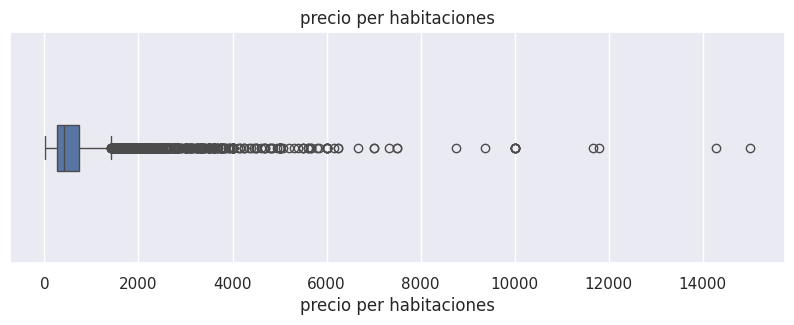

In [17]:
sns.set(rc={"figure.figsize":(10, 3)})
fig = sns.boxplot(data=df['precio'],width =0.2,orient="h")
plt.title('precio')
plt.show(fig)

fig = sns.set(rc={"figure.figsize":(10, 3)})
sns.boxplot(data=df['habitaciones'],width =0.2,orient="h")
plt.title('habitaciones')
plt.show(fig)

fig = sns.set(rc={"figure.figsize":(10, 3)})
sns.boxplot(data=df['metros'],width =0.2,orient="h")
plt.title('metros')
plt.show(fig)

fig = sns.set(rc={"figure.figsize":(10, 3)})
sns.boxplot(data=df['precio per metros'],width =0.2,orient="h")
plt.title('precio per metros')
plt.show(fig)

fig = sns.set(rc={"figure.figsize":(10, 3)})
sns.boxplot(data=df['precio per habitaciones'],width =0.2,orient="h")
plt.title('precio per habitaciones')
plt.show(fig)

In [18]:
provincia_stats = df.groupby('provincia').agg({"precio": [np.min, np.max, np.mean], 'precio per metros' : [np.min, np.max,np.mean],'precio per habitaciones' : [np.min, np.max, np.mean] })

fig = px.line(provincia_stats.precio['min'],title='Minimum rent',markers=True)
fig.update_layout(width=1200,
    height=1000,xaxis_title="Province", yaxis_title="Price"
)
fig.show()

fig = px.line(provincia_stats.precio['max'],title='Maximum rent',markers=True)
fig.update_layout(width=1200,
    height=1000,xaxis_title="Province", yaxis_title="Price"
)
fig.show()

fig = px.line(provincia_stats.precio['mean'],title='Average rent',markers=True)
fig.update_layout(width=1200,
    height=1000,xaxis_title="Province", yaxis_title="Price"
)
fig.show()


fig = px.line(provincia_stats['precio per metros']['min'],title='Minimum cost per m2',markers=True)
fig.update_layout(width=1200,
    height=1000,xaxis_title="Province", yaxis_title="Price"
)
fig.show()

fig = px.line(provincia_stats['precio per metros']['max'],title='Maximum cost per m2',markers=True)
fig.update_layout(width=1200,
    height=1000,xaxis_title="Province", yaxis_title="Price"
)
fig.show()

fig = px.line(provincia_stats['precio per metros']['mean'],title='Average cost per living room',markers=True)
fig.update_layout(width=1200,
    height=1000,xaxis_title="Province", yaxis_title="Price"
)
fig.show()



fig = px.line(provincia_stats['precio per habitaciones']['min'],title='Mininmum cost per living room',markers=True)
fig.update_layout(width=1200,
    height=1000,xaxis_title="Province", yaxis_title="Price"
)
fig.show()

fig = px.line(provincia_stats['precio per habitaciones']['max'],title='Maximum cost per living room',markers=True)
fig.update_layout(width=1200,
    height=1000,xaxis_title="Province", yaxis_title="Price"
)
fig.show()

fig = px.line(provincia_stats['precio per habitaciones']['mean'],title='Average cost per living room',markers=True)
fig.update_layout(width=1200,
    height=1000,xaxis_title="Province", yaxis_title="Price"
)
fig.show()



In [19]:
#adding a room type column
def extract_property_type(title):
    if not isinstance(title, str):
        return 'otros'

    title_lower = title.lower()

    if re.search(r'\bestudio\b', title_lower):
        return 'estudio'
    elif re.search(r'\bapartamento\b', title_lower):
        return 'apartamento'
    elif re.search(r'\bpiso\b', title_lower):
        return 'piso'
    elif re.search(r'\bático\b', title_lower):
        return 'ático'
    elif re.search(r'\bdúplex\b', title_lower):
        return 'dúplex'
    elif re.search(r'\bchalet\b', title_lower):
        return 'chalet'
    elif re.search(r'\bcasa\b', title_lower):
        return 'casa'
    elif re.search(r'\bloft\b', title_lower):
        return 'loft'
    elif re.search(r'\badosado\b', title_lower):
        return 'chalet adosado'
    elif re.search(r'\bpareado\b', title_lower):
        return 'chalet pareado'
    elif re.search(r'\brural\b', title_lower):
        return 'casa rural'
    else:
        return 'otros'

df['tipo_inmueble'] = df['titulo'].apply(extract_property_type)

In [20]:
#Adding a grupo_de_metros column and grouping by them
df['grupo_de_metros'] = (df['metros'] // 15).astype('Int64')
bucket_counts = df['grupo_de_metros'].value_counts().sort_index()
print("\nNumber of observations by buckets (each bucket = 20 м²):")
print(bucket_counts.head(10))

# Choose buckets
selected_buckets = bucket_counts[bucket_counts > 200].index.tolist()
selected_buckets = selected_buckets[:5]
print(f"\nSelected buckets for analysis: {selected_buckets}")


Number of observations by buckets (each bucket = 20 м²):
grupo_de_metros
1        55
2      2159
3     11578
4     11844
5     15894
6     10578
7      6080
8      5758
9      1760
10     2401
Name: count, dtype: Int64

Selected buckets for analysis: [2, 3, 4, 5, 6]


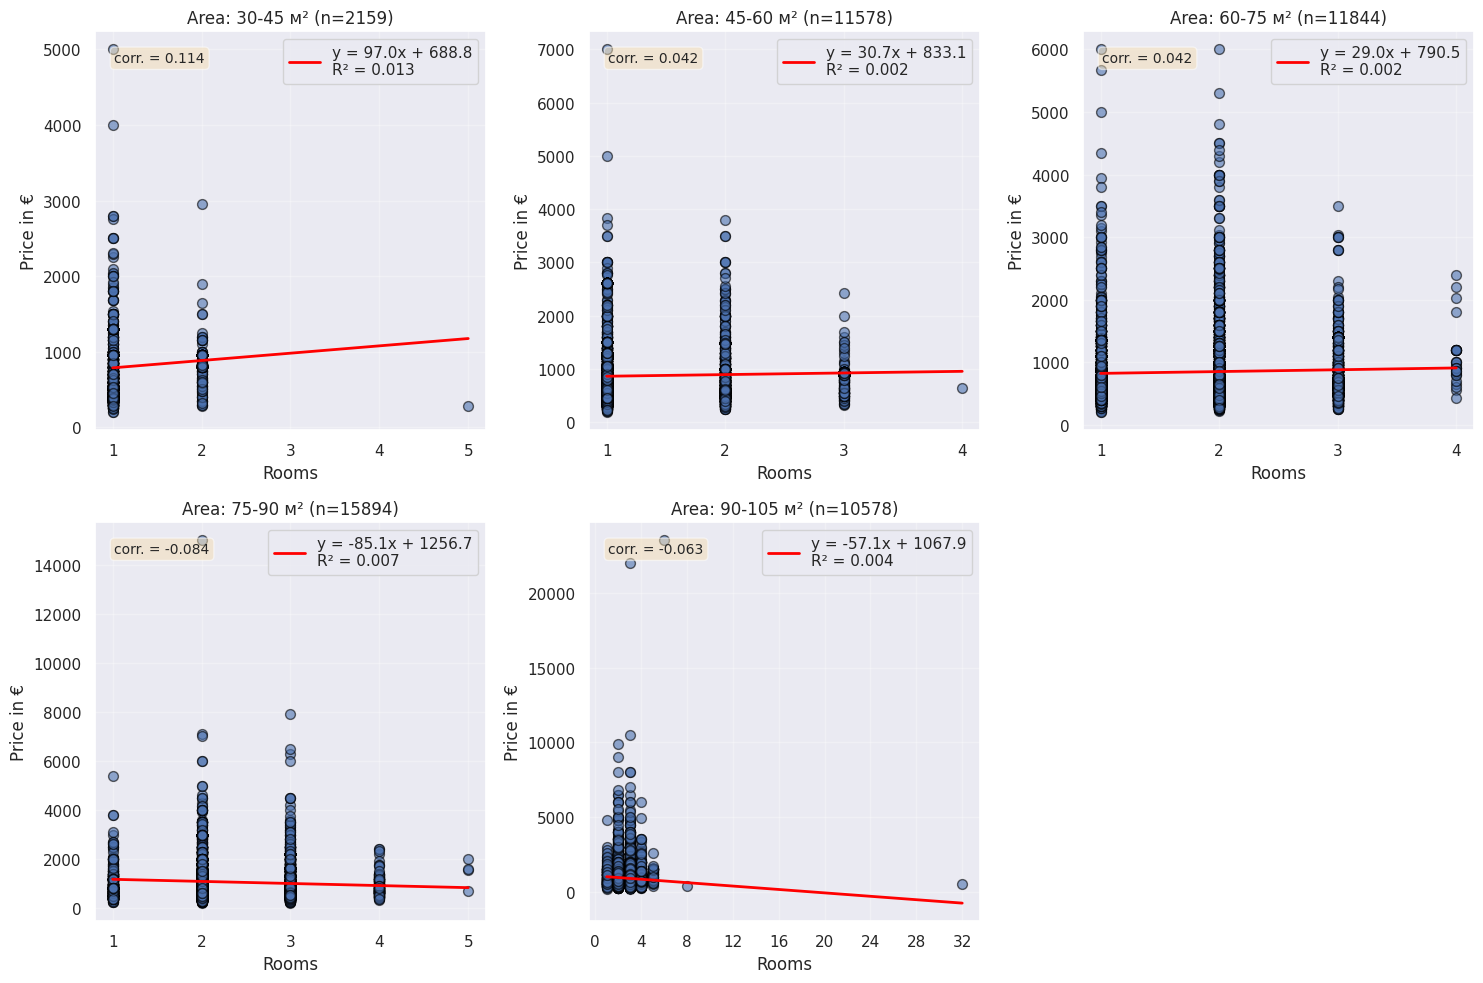


Correlation between the number of rooms and the bucket price:
Bucket 30-45 м²: correlation = 0.114 *** (n=2159)
Bucket 45-60 м²: correlation = 0.042 *** (n=11578)
Bucket 60-75 м²: correlation = 0.042 *** (n=11844)
Bucket 75-90 м²: correlation = -0.084 *** (n=15894)
Bucket 90-105 м²: correlation = -0.063 *** (n=10578)


In [21]:
#Building a scatter plot and regressions for selected buckets
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, bucket in enumerate(selected_buckets[:6]):
    bucket_data = df[df['grupo_de_metros'] == bucket].copy()


    # Scatter plot
    axes[i].scatter(bucket_data['habitaciones'], bucket_data['precio'],
                   alpha=0.6, s=50, edgecolor='black')

    x = bucket_data['habitaciones'].dropna()
    y = bucket_data['precio'].dropna()

    if len(x) > 1 and len(y) > 1:
        valid_idx = x.index.intersection(y.index)
        x_clean = x.loc[valid_idx]
        y_clean = y.loc[valid_idx]

        if len(x_clean) > 1:
            slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)

            x_line = np.array([x_clean.min(), x_clean.max()])
            y_line = intercept + slope * x_line

            axes[i].plot(x_line, y_line, color='red', linewidth=2,
                        label=f'y = {slope:.1f}x + {intercept:.1f}\nR² = {r_value**2:.3f}')

            correlation = bucket_data['habitaciones'].corr(bucket_data['precio'])
            axes[i].text(0.05, 0.95, f'corr. = {correlation:.3f}',
                        transform=axes[i].transAxes, fontsize=10,
                        verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    axes[i].set_title(f'Area: {bucket*15}-{(bucket+1)*15} м² (n={len(bucket_data)})')
    axes[i].set_xlabel('Rooms')
    axes[i].set_ylabel('Price in €')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

    axes[i].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


print("\nCorrelation between the number of rooms and the bucket price:")
for bucket in selected_buckets:
    bucket_data = df[df['grupo_de_metros'] == bucket]
    correlation = bucket_data['habitaciones'].corr(bucket_data['precio'])
    n = len(bucket_data)

    # Statistical significance
    if n > 2 and not pd.isna(correlation):
        t_stat = correlation * np.sqrt((n-2)/(1-correlation**2))
        p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n-2))
        sig_stars = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
    else:
        p_value = np.nan
        sig_stars = ""

    print(f"Bucket {bucket*15}-{(bucket+1)*15} м²: correlation = {correlation:.3f} {sig_stars} (n={n})")







In [24]:
#Conclusion
print("CONCLUSION:")

#Calculating positive correlations
positive_corr = 0
total_buckets = 0

for bucket in selected_buckets:
    bucket_data = df[df['grupo_de_metros'] == bucket]
    correlation = bucket_data['habitaciones'].corr(bucket_data['precio'])
    if not pd.isna(correlation) and correlation > 0:
        positive_corr += 1
    total_buckets += 1

if positive_corr / total_buckets > 0.5:
    print(f"The hypothesis IS CONFIRMED: in {positive_corr} from {total_buckets} buckets")
    print("There is a positive correlation between the number of rooms and the price.")
    print("This means that within the same area category apartments with more rooms are usually more expensive.")
else:
    print(f"✗ The hypothesis IS NOT CONFIRMED: only in {positive_corr} from {total_buckets} buckets")
    print("  there is a positive correlation.")

CONCLUSION:
The hypothesis IS CONFIRMED: in 3 from 5 buckets
There is a positive correlation between the number of rooms and the price.
This means that within the same area category apartments with more rooms are usually more expensive.


In [25]:
#Analysis by type of real estate
print("\n1. Average price per m2 by property type:")
type_stats = df.groupby('tipo_inmueble')['precio per metros'].agg(['mean', 'count']).round(2)
type_stats = type_stats.sort_values('mean', ascending=False)
type_stats.head(10)


1. Average price per m2 by property type:


,mean,count
tipo_inmueble,,
ático,16.16,3562
piso,12.77,60345
dúplex,12.57,3475
otros,11.76,232
chalet,11.59,7326
estudio,8.65,1
casa,7.77,690


In [26]:
#The most expensive and cheapest buckets
print("\n2. The most expensive/cheapest area ranges:")
area_stats = df.groupby('grupo_de_metros')['precio per metros'].agg(['mean', 'count']).round(2)
area_stats = area_stats.sort_values('mean', ascending=False)
print("Top-5 most expensive:")
print(area_stats.head())
print("\nТоп-5 cheapest:")
print(area_stats.tail())


2. The most expensive/cheapest area ranges:
Top-5 most expensive:
                  mean  count
grupo_de_metros              
59               57.82      2
47               26.44      6
37               25.79     12
1                23.49     55
65               21.83      2

Топ-5 cheapest:
                 mean  count
grupo_de_metros             
64               6.93      5
22               6.59    680
60               5.71      7
63               4.81      3
66               1.95      2
